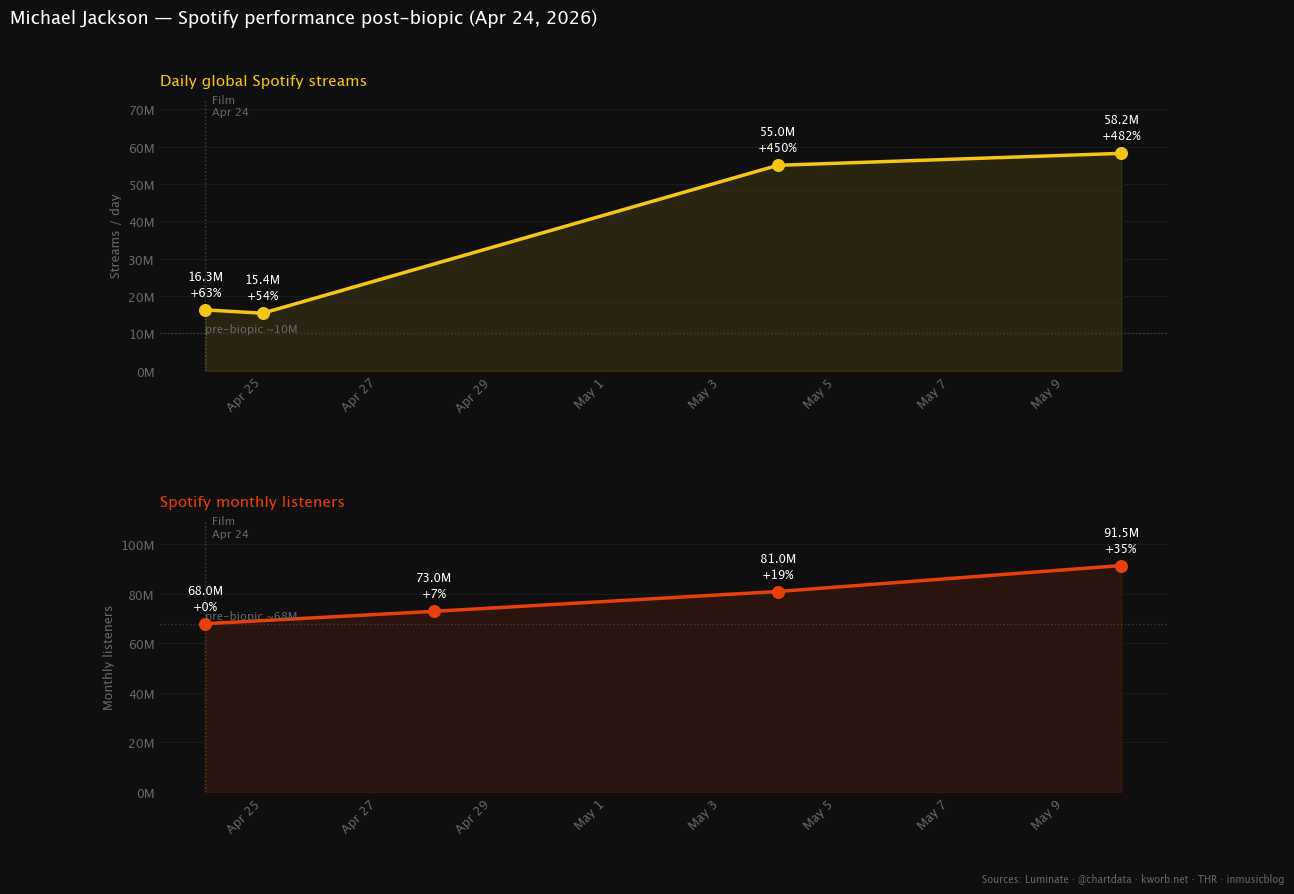


                           Peak             Latest  vs Baseline
──────────────────────────────────────────────────────────────
Streams          58.2M (May 10)     58.2M (May 10)        +482%
Listeners        91.5M (May 10)     91.5M (May 10)         +35%


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# ─── CHECK KWORB DAILY: kworb.net/spotify/artist/3fMbdgg4jU18AjLCKBhRSm_songs.html
streams_data = [                                  # ('YYYY-MM-DD', millions, 'source')
    ('2026-04-24', 16.3, 'Luminate (opening day, Fri)'),
    ('2026-04-25', 15.4, 'Luminate (Sat — 31.7M combined)'),
    ('2026-05-04', 55.0, '@chartdata'),
    ('2026-05-10', 58.2, 'kworb'),
]

# ─── CHECK SPOTIFY ARTIST PAGE FOR MONTHLY LISTENERS
listeners_data = [                                # ('YYYY-MM-DD', millions)
    ('2026-04-24', 68.0),
    ('2026-04-28', 73.0),
    ('2026-05-04', 81.0),
    ('2026-05-10', 91.5),
]
# ───────────────────────────────────────────────────────────────────────────

YELLOW = '#F5C518'; RED = '#E8400A'; BG = '#0f0f0f'
GRID   = '#1e1e1e'; MUTED = '#666666'; WHITE = '#ffffff'
STREAMS_BASELINE = 10.0; LISTENERS_BASELINE = 68.0

def parse_sort(data):
    parsed = sorted([(datetime.strptime(r[0], '%Y-%m-%d'), r[1]) for r in data])
    return [p[0] for p in parsed], [p[1] for p in parsed]

def pct_label(v, base):
    return f"{'+' if v >= base else ''}{((v - base) / base * 100):.0f}%"

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.grid(axis='y', color=GRID, linewidth=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %-d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', color=MUTED, fontsize=9)
    plt.setp(ax.get_yticklabels(), color=MUTED, fontsize=9)

def plot_series(ax, dates, values, color, baseline, ylabel, ypad=1.25):
    ymax = max(values) * ypad
    ax.fill_between(dates, values, alpha=0.12, color=color)
    ax.plot(dates, values, color=color, linewidth=2.5, zorder=3)
    ax.scatter(dates, values, color=color, s=70, zorder=5)
    ax.set_ylim(0, ymax)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.axhline(y=baseline, color=MUTED, linewidth=1, linestyle=':', alpha=0.5)
    ax.text(dates[0], baseline * 1.03, f'pre-biopic ~{baseline:.0f}M', color=MUTED, fontsize=8)
    for d, v in zip(dates, values):
        ax.annotate(f'{v:.1f}M\n{pct_label(v, baseline)}', xy=(d, v), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=8.5,
                    color=WHITE, fontweight='bold', linespacing=1.4)
    ax.axvline(x=datetime(2026, 4, 24), color=WHITE, linewidth=1, linestyle=':', alpha=0.2)
    ax.text(datetime(2026, 4, 24), ymax * 0.94, '  Film\n  Apr 24', color=MUTED, fontsize=8)

# ── Build figure ──────────────────────────────────────────────────────────────
s_dates, s_values = parse_sort(streams_data)
l_dates, l_values = parse_sort(listeners_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=False)
fig.patch.set_facecolor(BG)
fig.subplots_adjust(hspace=0.55)

style_ax(ax1)
plot_series(ax1, s_dates, s_values, YELLOW, STREAMS_BASELINE, 'Streams / day')
ax1.set_title('Daily global Spotify streams', color=YELLOW, fontsize=11, fontweight='bold', pad=10, loc='left')

style_ax(ax2)
plot_series(ax2, l_dates, l_values, RED, LISTENERS_BASELINE, 'Monthly listeners', ypad=1.2)
ax2.set_ylim(0, max(l_values) * 1.2)
ax2.set_title('Spotify monthly listeners', color=RED, fontsize=11, fontweight='bold', pad=10, loc='left')

fig.suptitle('Michael Jackson — Spotify performance post-biopic (Apr 24, 2026)',
             color=WHITE, fontsize=13, fontweight='bold', x=0.01, ha='left', y=0.98)
fig.text(0.99, 0.01, 'Sources: Luminate · @chartdata · kworb.net · THR · inmusicblog',
         ha='right', fontsize=7, color=MUTED)

plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
col = {'metric': 12, 'peak': 18, 'latest': 18, 'pct': 12}
s_peak = f"{max(s_values):.1f}M ({s_dates[s_values.index(max(s_values))]:%b %-d})"
s_late = f"{s_values[-1]:.1f}M ({s_dates[-1]:%b %-d})"
l_peak = f"{max(l_values):.1f}M ({l_dates[l_values.index(max(l_values))]:%b %-d})"
l_late = f"{l_values[-1]:.1f}M ({l_dates[-1]:%b %-d})"

print(f"\n{'':>{col['metric']}} {'Peak':>{col['peak']}} {'Latest':>{col['latest']}} {'vs Baseline':>{col['pct']}}")
print('─' * (sum(col.values()) + 2))
print(f"{'Streams':<{col['metric']}} {s_peak:>{col['peak']}} {s_late:>{col['latest']}} {pct_label(s_values[-1], STREAMS_BASELINE):>{col['pct']}}")
print(f"{'Listeners':<{col['metric']}} {l_peak:>{col['peak']}} {l_late:>{col['latest']}} {pct_label(l_values[-1], LISTENERS_BASELINE):>{col['pct']}}")